# Zero-Inflated Gamma (ZIG) Precipitation Model

A single-model replacement for the two-step occurrence/intensity approach in Anderson et al. (2016). This notebook loads the precipitation data, trains a ZIG-Gamma mixture model, evaluates its skill through calibration checks, and decomposes the potential predictable variance (PPV) by frequency band.

All function definitions have been extracted into separate `.py` modules. This notebook focuses on execution and analysis.

## Imports and configuration

In [1]:
import numpy as np
import torch

from precip_io import load_precip_txt
from features import build_features, compute_in_features
from model import ZIGammaMLP
from train import train_zig
from simulate import monte_carlo_simulate
from metrics import (
    annual_metrics,
    compute_annual_metrics_ts,
    compute_ppv,
    compute_normalized_ppv,
    reliability_diagram,
    expected_calibration_error,
    intensity_qq_stats,
)
from spectral import multitaper_psd, spectral_ppv_decompose
from plot import (
    plot_loss_curves,
    plot_single_member_intensity,
    plot_reliability_diagram,
    plot_intensity_qq,
    plot_ppv_anderson,
    plot_ppv_normalized,
    plot_spectral_ppv,
    plot_ppv_comparison,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Config

In [2]:
# =============================================================================
# USER PARAMETERS — edit this cell to configure the analysis
# =============================================================================

# --- Data ---
DATA_FILE = "data/actual/daily_tot_stat564.txt"  # path to .txt or .npz file
WET_THRESHOLD = 1.0   # mm; days below this are "dry"
N_INT_LAGS = 5        # lagged intensity features (0 = occurrence-only mode)
N_VAL_YEARS = 20      # hold-out years for validation (chronological)

# --- Model architecture ---
HIDDEN_SIZES = (32, 32)
N_COMPONENTS = 2      # gamma mixture components
DROPOUT = 0.0
RANDOM_SEED = 66       # for reproducibility; set to None for random initialization
torch.manual_seed(RANDOM_SEED)

# --- Training ---
N_EPOCHS = 3000
BATCH_SIZE = 128
LR = 1.0e-3
PATIENCE = 50         # early stopping: epochs without improvement
MIN_DELTA = 1e-4      # minimum validation loss improvement
WEIGHT_DECAY = 1e-4

# --- Simulation ---
N_SIMULATIONS = 1_000   # ensemble members (paper uses 1000 for full runs)

# --- Spectral analysis ---
MULTITAPER_NW = 4.0   # time-half-bandwidth product (creates 2*NW-1 tapers)

## Data Loading

Load precipitation from a station text file (365 rows × N_years columns, whitespace-delimited, mm) or synthetic .npz. The file is parsed and lagged occurrence/intensity features are computed.

In [3]:
# ── Load from file ────────────────────────────────────────────────────────────
if DATA_FILE is not None:
    if str(DATA_FILE).endswith(".txt"):
        _d = load_precip_txt(DATA_FILE, wet_threshold=WET_THRESHOLD, n_lags=5)
    else:
        _d = np.load(DATA_FILE)

    doy = _d["doy"]
    occ_lags = _d["occ_lags"]
    occ_obs = _d["occ_obs"]
    int_obs = _d["int_obs"]

    N_DAYS = len(doy)
    N_LAGS = occ_lags.shape[1]
    y_all = torch.from_numpy(int_obs)

    print(f"Loaded: {DATA_FILE}")
else:
    raise ValueError("DATA_FILE must be set")

# ── Build lagged intensity features ───────────────────────────────────────────
if N_INT_LAGS > 0:
    int_lags = np.zeros((N_DAYS, N_INT_LAGS), dtype=np.float32)
    for j in range(N_INT_LAGS):
        lag = N_INT_LAGS - j
        int_lags[lag:, j] = int_obs[:N_DAYS - lag]
else:
    int_lags = None

# ── Assemble full input tensor ────────────────────────────────────────────────
X_all = build_features(doy, occ_lags, int_lags)

# ── Chronological train/validation split ──────────────────────────────────────
N_VAL = N_VAL_YEARS * 365
N_TRAIN = N_DAYS - N_VAL

if N_TRAIN <= 0:
    raise ValueError(
        f"N_VAL_YEARS={N_VAL_YEARS} leaves no training data "
        f"(record is only {N_DAYS // 365} years)."
    )

X_train, X_val = X_all[:N_TRAIN], X_all[N_TRAIN:]
y_train, y_val = y_all[:N_TRAIN], y_all[N_TRAIN:]

print(
    f"N={N_DAYS}  |  n_occ_lags={N_LAGS}  |  n_int_lags={N_INT_LAGS}  "
    f"|  in_features={X_all.shape[1]}"
)
print(
    f"Train: {N_TRAIN} days ({N_TRAIN // 365} yr)  |  "
    f"Val: {N_VAL} days ({N_VAL_YEARS} yr)"
)
print(
    f"Wet fraction : {(occ_obs > 0).mean():.2f}  |  "
    f"Mean intensity (wet days): {int_obs[occ_obs > 0].mean():.1f} mm"
)

Loaded: data/actual/daily_tot_stat564.txt
N=35040  |  n_occ_lags=5  |  n_int_lags=5  |  in_features=12
Train: 27740 days (76 yr)  |  Val: 7300 days (20 yr)
Wet fraction : 0.34  |  Mean intensity (wet days): 9.1 mm


## Model & Training

Instantiate the ZIG-Gamma mixture model and train with early stopping on the validation set.

In [4]:
n_in = compute_in_features(N_LAGS, N_INT_LAGS)
model = ZIGammaMLP(
    n_in,
    hidden_sizes=HIDDEN_SIZES,
    n_components=N_COMPONENTS,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

history = train_zig(
    model,
    X_train,
    y_train,
    x_val=X_val,
    y_val=y_val,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
)

Parameters: 1,831
  epoch   10/3000  train NLL=1.5310  val NLL=1.5639
  epoch   20/3000  train NLL=1.5275  val NLL=1.5627
  epoch   30/3000  train NLL=1.5244  val NLL=1.5653
  epoch   40/3000  train NLL=1.5224  val NLL=1.5634
  epoch   50/3000  train NLL=1.5202  val NLL=1.5685
  epoch   60/3000  train NLL=1.5176  val NLL=1.5689
  Early stop at epoch 69 (best val NLL=1.5617 at epoch 19)


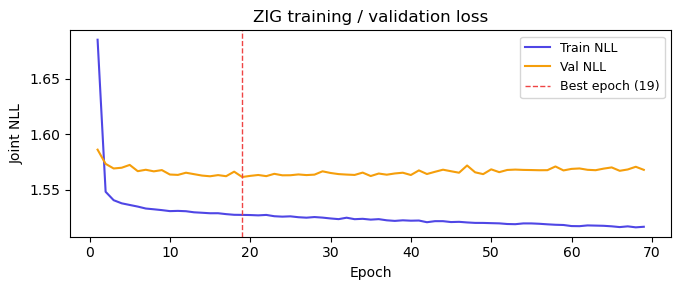

In [5]:
plot_loss_curves(history)

## Monte Carlo Simulation

Forward-integrate the trained model over the full record to generate N_SIMULATIONS ensemble members.

In [6]:
occ_sim, int_sim = monte_carlo_simulate(
    model,
    doy_sequence=doy,
    n_lags=N_LAGS,
    n_int_lags=N_INT_LAGS,
    n_simulations=N_SIMULATIONS,
    wet_threshold=WET_THRESHOLD,
    device=DEVICE,
)
print(f"occ_sim shape: {occ_sim.shape}  |  int_sim shape: {int_sim.shape}")

occ_sim shape: (1000, 35040)  |  int_sim shape: (1000, 35040)


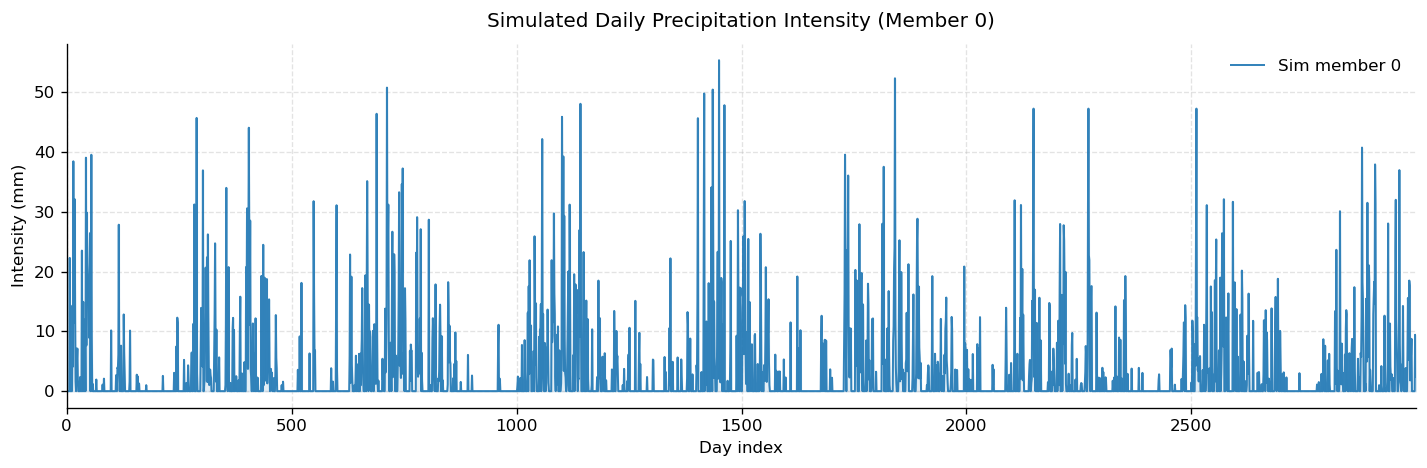

In [7]:
plot_single_member_intensity(int_sim, member=0)

## Calibration Checks

Evaluate the model's ability to predict the correct probabilities and intensities.

Occurrence ECE = 0.0099  (0 = perfect; < 0.05 = good)


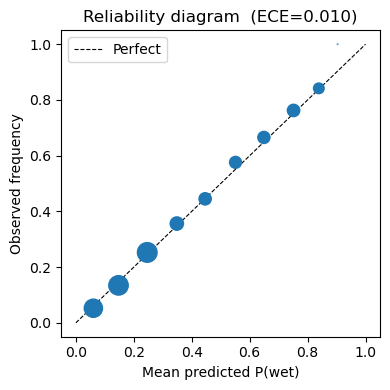

In [8]:
model.eval()
prob_pred = model.p_wet(X_val).detach().cpu().numpy()
y_val_np = y_val.detach().cpu().numpy()

centres, freqs, counts = reliability_diagram(prob_pred, y_val_np)
ece = expected_calibration_error(centres, freqs, counts)
print(f"Occurrence ECE = {ece:.4f}  (0 = perfect; < 0.05 = good)")

# plot_reliability_diagram re-runs binning internally; pass raw arrays
plot_reliability_diagram(prob_pred, y_val_np)

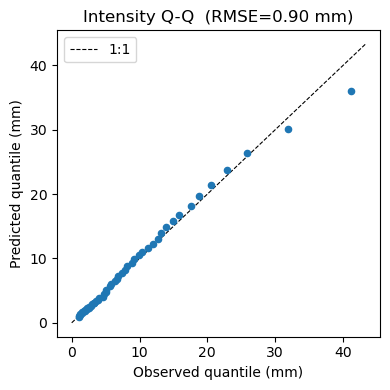

In [9]:
wet_mask = y_val_np >= WET_THRESHOLD
X_val_wet = X_val[wet_mask]
y_val_wet = y_val_np[wet_mask]

q_obs, q_pred = intensity_qq_stats(model, X_val_wet, y_val_wet, device=DEVICE)

plot_intensity_qq(q_obs, q_pred)

## Potential Predictable Variance (PPV)

Replicates **Equation 1** from Anderson et al. (2016):

$$\mathrm{PPV(var)} = \frac{\sigma^2_{\mathrm{obs}} - \overline{\sigma^2_{\mathrm{sim}}}}{\sigma^2_{\mathrm{obs}}}$$

where

- $\sigma^2_{\mathrm{obs}}$ — observed year-to-year variance in the annual metric (OCC, SII, or TOT);
- $\sigma^2_{\mathrm{sim}}(n)$ — year-to-year variance of the *n*-th simulated ensemble member;
- $\overline{\sigma^2_{\mathrm{sim}}}$ — **mean of the per-member variances** (variance computed before averaging).

PPV = 1 means all observed inter-annual variance is predictable; PPV = 0 means none; negative values indicate the stochastic model produces more variance than observed.

In [10]:
occ_obs_full = (int_obs >= WET_THRESHOLD).astype(np.float32)

ppv_results = compute_ppv(
    occ_obs=occ_obs_full,
    int_obs=int_obs,
    occ_sim=occ_sim,
    int_sim=int_sim,
    days_per_year=365,
)

print("Anderson et al. (2016) Eq. 1 — Potential Predictable Variance")
print("=" * 58)
print(f"{'Metric':<6}  {'σ²_obs':>10}  {'mean(σ²_sim)':>12}  {'PPV':>8}")
print("-" * 58)
for key, d in ppv_results.items():
    print(
        f"{key:<6}  {d['var_obs']:>10.3f}  "
        f"{d['mean_var_sim']:>12.3f}  {d['ppv']:>8.3f}"
    )
print()
print(
    "Note: PPV > 0 → observed variance exceeds stochastic baseline\n"
    "      PPV ≤ 0 → no detectable signal above weather noise"
)

Anderson et al. (2016) Eq. 1 — Potential Predictable Variance
Metric      σ²_obs  mean(σ²_sim)       PPV
----------------------------------------------------------
OCC        239.560       208.302     0.130
SII          1.434         1.002     0.301
TOT      53116.561     40279.796     0.242

Note: PPV > 0 → observed variance exceeds stochastic baseline
      PPV ≤ 0 → no detectable signal above weather noise


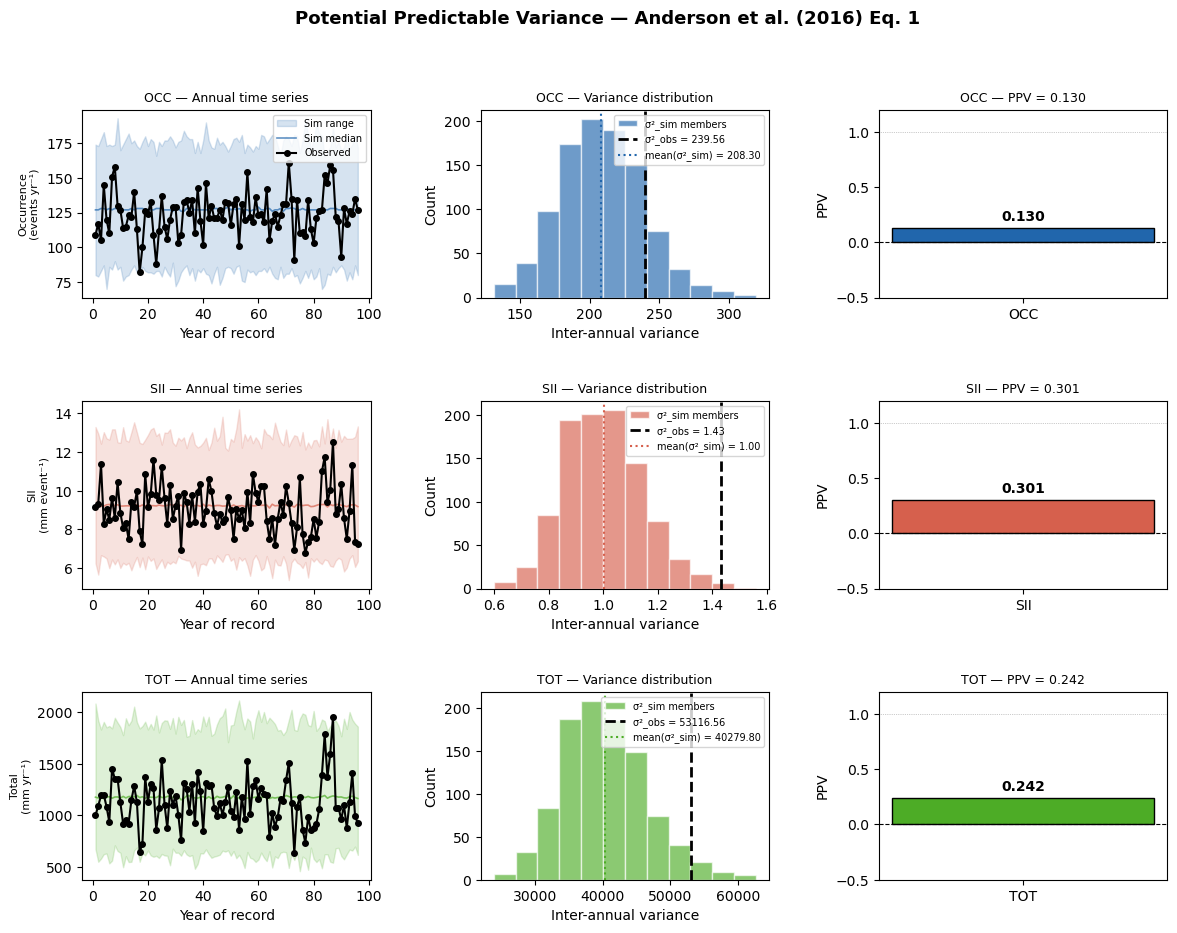

In [11]:
plot_ppv_anderson(ppv_results)

## Normalized PPV and Significance Testing

Test significance by comparing the observed PPV against a null distribution formed by computing the within-ensemble PPV (Equations 7–8 from Anderson et al. 2016):

For each ensemble member $n$, the null PPV is:
$$\widetilde{\mathrm{PPV}}(n) = \frac{\sigma^2_{\mathrm{sim}}(n) - \overline{\sigma^2_{\mathrm{sim}}}}{\sigma^2_{\mathrm{sim}}(n)}$$

The 90th percentile of this distribution is the threshold; normalized PPV > 1 indicates significance at p < 0.10.

Normalized PPV — Anderson et al. (2016) significance framework
  Metric   PPV_obs   threshold   Norm. PPV  Significant?
  --------------------------------------------------------
  OCC        0.130      0.1548        0.84            no
  SII        0.301      0.1556        1.94  YES (p<0.10)
  TOT        0.242      0.1668        1.45  YES (p<0.10)

  Normalized PPV > 1 → observed variance significantly exceeds
  the stochastic baseline at the directional p < 0.10 level.
  Note: ensemble size S = 1000 (paper uses 1000).


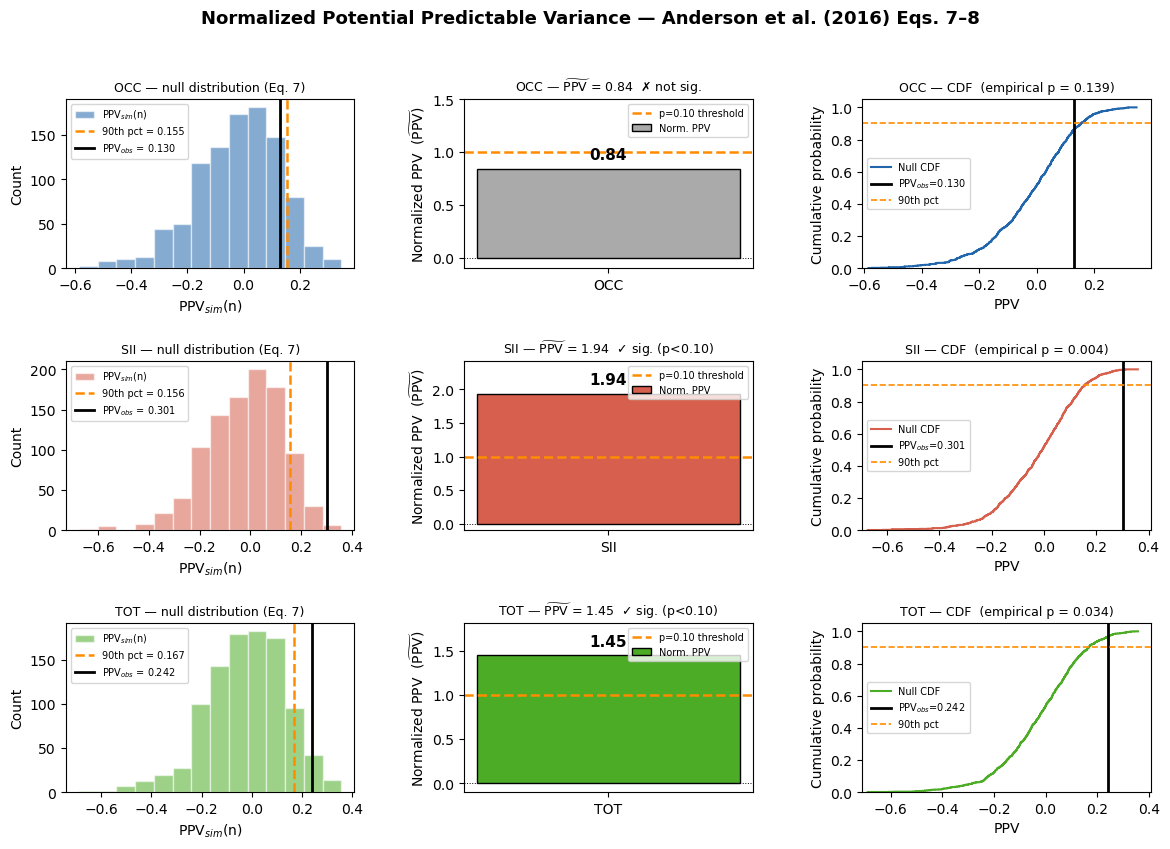

In [12]:
ppv_norm_results = compute_normalized_ppv(ppv_results)

print("Normalized PPV — Anderson et al. (2016) significance framework")
print("=" * 66)
print(
    f"  {'Metric':<6}  {'PPV_obs':>8}  {'threshold':>10}"
    f"  {'Norm. PPV':>10}  {'Significant?':>12}"
)
print("  " + "-" * 56)
for key, d in ppv_norm_results.items():
    sig = "YES (p<0.10)" if d["ppv_normalized"] > 1 else "no"
    print(
        f"  {key:<6}  {d['ppv']:>8.3f}  {d['threshold_p10']:>10.4f}"
        f"  {d['ppv_normalized']:>10.2f}  {sig:>12}"
    )
print()
print(
    f"  Normalized PPV > 1 → observed variance significantly exceeds\n"
    f"  the stochastic baseline at the directional p < 0.10 level.\n"
    f"  Note: ensemble size S = {int_sim.shape[0]} (paper uses 1000)."
)

plot_ppv_normalized(ppv_norm_results)

## Frequency Decomposition

Decompose the PPV into frequency-band contributions using multitaper spectral analysis (Equations 2–6 from Anderson et al. 2016).

The total PPV partitions exactly as:
$$\mathrm{PPV} = \sum_{\mathrm{bands}} \mathrm{PP(band)} + \mathrm{PP(trend)}$$

Frequency bands are defined in cycles per year:
- 2–7 yr (inter-annual)
- 7–20 yr (decadal)
- 20–40 yr (multi-decadal)
- `> 40 yr (low-frequency)
- trend (secular change)

In [13]:
ppv_spectral = {}
ppv_spectral_meta = {}

for key in ("OCC", "SII", "TOT"):
    band_results, meta = spectral_ppv_decompose(
        ann_obs=ppv_results[key]["ann_obs"],
        ann_sim=ppv_results[key]["ann_sim"],
        var_obs_full=ppv_results[key]["var_obs"],
        NW=MULTITAPER_NW,
    )
    ppv_spectral[key] = band_results
    ppv_spectral_meta[key] = meta

print("Frequency-decomposed Normalized PPV — Anderson et al. (2016) Eqs. 2–6")
print("=" * 68)
print(f"  {'Band':<10}" + "".join(f"  {k:>10}" for k in ("OCC", "SII", "TOT")))
print("  " + "-" * 58)

from spectral import BAND_ORDER
for band in BAND_ORDER:
    row = f"  {band:<10}"
    for key in ("OCC", "SII", "TOT"):
        d = ppv_spectral[key][band]
        v = d["ppv_normalized"]
        sig = "*" if (not np.isnan(v) and v > 1.0) else " "
        row += f"  {v:>9.2f}{sig}"
    print(row)
print()
print("  * = significant at p < 0.10 (normalized PPV > 1)")

Frequency-decomposed Normalized PPV — Anderson et al. (2016) Eqs. 2–6
  Band               OCC         SII         TOT
  ----------------------------------------------------------
  2-7yr            0.07        0.75        0.18 
  7-20yr           1.37*       1.75*       2.60*
  20-40yr          1.14*       2.71*       2.53*
  >40yr           -0.09        1.50*       0.23 
  trend            0.56        0.10       -0.36 

  * = significant at p < 0.10 (normalized PPV > 1)


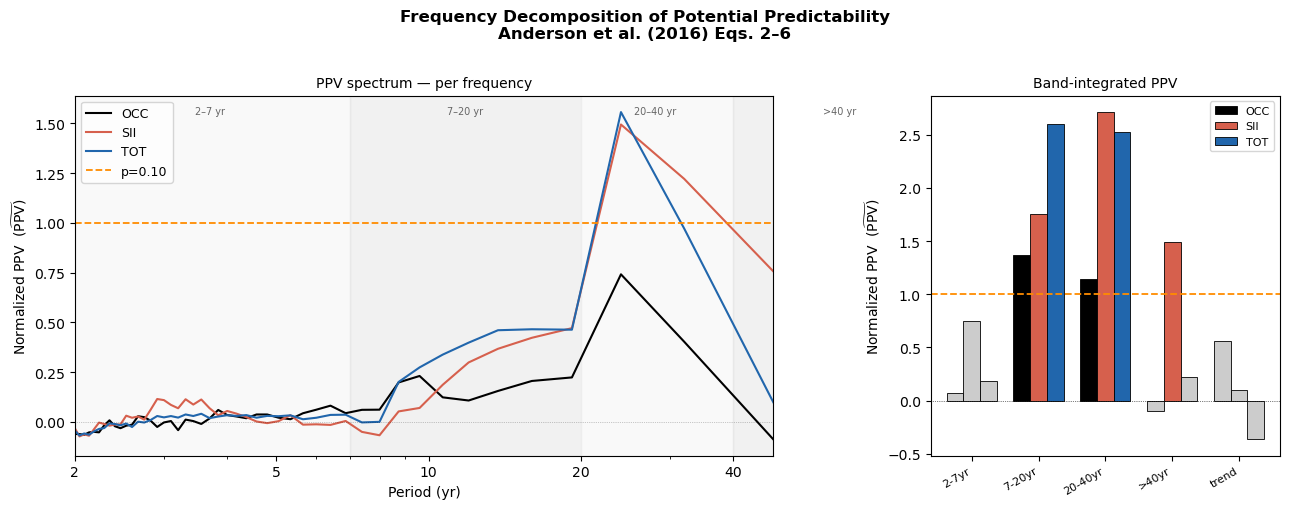

In [14]:
plot_spectral_ppv(ppv_results, ppv_spectral, ppv_spectral_meta)

## Markov Model Comparison

Compare the ZIG-derived PPV values against those from a 1,000-member simple Markov model ensemble provided by a colleague (`data/synthetic/daily_tot_stat564_sim.txt`). The Markov ensemble spans the same 96-year record as the observed data. Each of the three steps below mirrors the ZIG pipeline: load → PPV → spectral decomposition → comparison plot.

### Step 1 — Load Markov Ensemble

The file is stored as (n_days × n_sims): 35,040 rows × 1,000 columns, whitespace-delimited. Days run chronologically down the rows (year 1 days 1–365, then year 2 days 1–365, …). We use `pandas.read_csv` rather than `np.loadtxt` because the file is large enough that `loadtxt` is substantially slower on plain-text input of this size.

After loading we:
1. Assert the shape matches the expected 365 × 96 days and 1,000 simulations.
2. Transpose to `(n_sims, n_days)` — matching the `(N_SIMULATIONS, T)` convention of `occ_sim` / `int_sim`.
3. Derive binary occurrence (`markov_occ_sim`) and intensity (`markov_int_sim`) by applying the same `WET_THRESHOLD` used throughout this notebook.

In [15]:
import pandas as pd

MARKOV_FILE = "data/synthetic/daily_tot_stat564_sim.txt"
N_MARKOV_SIMS = 1000
N_MARKOV_YEARS = 96  # same record length as observed data

# ── Read file ──────────────────────────────────────────────────────────────────
# Stored as (n_days, n_sims): 35,040 rows × 1,000 columns, whitespace-delimited.
# pandas.read_csv is used in place of np.loadtxt for speed on large text files.
_markov_df = pd.read_csv(MARKOV_FILE, sep=r"\s+", header=None, dtype=np.float32)
markov_raw = _markov_df.to_numpy()  # shape: (35040, 1000)
del _markov_df  # free the DataFrame immediately; we only need the array

# ── Shape check ────────────────────────────────────────────────────────────────
_expected_shape = (N_MARKOV_YEARS * 365, N_MARKOV_SIMS)
assert markov_raw.shape == _expected_shape, (
    f"Unexpected shape {markov_raw.shape}; expected {_expected_shape}. "
    "Check N_MARKOV_YEARS and N_MARKOV_SIMS."
)

# ── Transpose to (n_sims, n_days) ──────────────────────────────────────────────
# Matches the (N_SIMULATIONS, T) convention used by occ_sim / int_sim.
markov_raw = markov_raw.T  # shape: (1000, 35040)

# ── Derive occurrence and intensity ────────────────────────────────────────────
# Apply the same WET_THRESHOLD as the rest of the notebook.
markov_occ_sim = (markov_raw >= WET_THRESHOLD).astype(np.float32)  # (1000, 35040)
markov_int_sim = markov_raw  # (1000, 35040); 0.0 on dry days

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Loaded: {MARKOV_FILE}")
print(f"  Shape (n_sims × n_days) : {markov_raw.shape}")
print(f"  Wet fraction            : {markov_occ_sim.mean():.3f}  (observed: 0.34)")
print(
    f"  Mean intensity (wet days): "
    f"{markov_int_sim[markov_occ_sim > 0].mean():.1f} mm  (observed: 9.1 mm)"
)

Loaded: data/synthetic/daily_tot_stat564_sim.txt
  Shape (n_sims × n_days) : (1000, 35040)
  Wet fraction            : 0.324  (observed: 0.34)
  Mean intensity (wet days): 9.6 mm  (observed: 9.1 mm)


### Step 2 — PPV and Spectral Decomposition

Run the Markov ensemble through the same three-stage pipeline used for ZIG:

1. `compute_ppv` → raw PPV scalars and annual time series per metric (OCC, SII, TOT)
2. `compute_normalized_ppv` → significance-tested normalized PPV
3. `spectral_ppv_decompose` → frequency-band decomposition

The observed arrays (`occ_obs_full`, `int_obs`) are unchanged — only the simulated ensemble is swapped. All Markov results carry a `_markov` suffix so ZIG results remain available for the comparison plot in Step 3.

Note: `compute_ppv` loops over ensemble members in Python; with S=1,000 this takes roughly twice as long as the ZIG run.

In [16]:
# ── Stage 1: Raw PPV (Anderson et al. 2016 Eq. 1) ────────────────────────────
# occ_obs_full and int_obs are identical to the ZIG run; only the ensemble
# (markov_occ_sim, markov_int_sim) is substituted.
ppv_results_markov = compute_ppv(
    occ_obs=occ_obs_full,
    int_obs=int_obs,
    occ_sim=markov_occ_sim,
    int_sim=markov_int_sim,
    days_per_year=365,
)

print("Markov — Anderson et al. (2016) Eq. 1 — Potential Predictable Variance")
print("=" * 58)
print(f"{'Metric':<6}  {'σ²_obs':>10}  {'mean(σ²_sim)':>12}  {'PPV':>8}")
print("-" * 58)
for key, d in ppv_results_markov.items():
    print(
        f"{key:<6}  {d['var_obs']:>10.3f}  "
        f"{d['mean_var_sim']:>12.3f}  {d['ppv']:>8.3f}"
    )

Markov — Anderson et al. (2016) Eq. 1 — Potential Predictable Variance
Metric      σ²_obs  mean(σ²_sim)       PPV
----------------------------------------------------------
OCC        239.560       150.869     0.370
SII          1.434         0.840     0.414
TOT      53116.561     24605.133     0.537


In [17]:
# ── Stage 2: Normalized PPV and significance testing (Anderson Eqs. 7–8) ──────
ppv_norm_results_markov = compute_normalized_ppv(ppv_results_markov)

print("Markov — Normalized PPV — Anderson et al. (2016) significance framework")
print("=" * 66)
print(
    f"  {'Metric':<6}  {'PPV_obs':>8}  {'threshold':>10}"
    f"  {'Norm. PPV':>10}  {'Significant?':>12}"
)
print("  " + "-" * 56)
for key, d in ppv_norm_results_markov.items():
    sig = "YES (p<0.10)" if d["ppv_normalized"] > 1 else "no"
    print(
        f"  {key:<6}  {d['ppv']:>8.3f}  {d['threshold_p10']:>10.4f}"
        f"  {d['ppv_normalized']:>10.2f}  {sig:>12}"
    )
print()
print(f"  Ensemble size S = {markov_int_sim.shape[0]}")

Markov — Normalized PPV — Anderson et al. (2016) significance framework
  Metric   PPV_obs   threshold   Norm. PPV  Significant?
  --------------------------------------------------------
  OCC        0.370      0.1610        2.30  YES (p<0.10)
  SII        0.414      0.1692        2.45  YES (p<0.10)
  TOT        0.537      0.1619        3.32  YES (p<0.10)

  Ensemble size S = 1000


In [18]:
# ── Stage 3: Frequency-band decomposition (Anderson Eqs. 2–6) ────────────────
ppv_spectral_markov = {}
ppv_spectral_meta_markov = {}

for key in ("OCC", "SII", "TOT"):
    band_results, meta = spectral_ppv_decompose(
        ann_obs=ppv_results_markov[key]["ann_obs"],
        ann_sim=ppv_results_markov[key]["ann_sim"],
        var_obs_full=ppv_results_markov[key]["var_obs"],
        NW=MULTITAPER_NW,
    )
    ppv_spectral_markov[key] = band_results
    ppv_spectral_meta_markov[key] = meta

print("Markov — Frequency-decomposed Normalized PPV — Anderson et al. (2016) Eqs. 2–6")
print("=" * 68)
print(f"  {'Band':<10}" + "".join(f"  {k:>10}" for k in ("OCC", "SII", "TOT")))
print("  " + "-" * 58)

from spectral import BAND_ORDER

for band in BAND_ORDER:
    row = f"  {band:<10}"
    for key in ("OCC", "SII", "TOT"):
        d = ppv_spectral_markov[key][band]
        v = d["ppv_normalized"]
        sig = "*" if (not np.isnan(v) and v > 1.0) else " "
        row += f"  {v:>9.2f}{sig}"
    print(row)
print()
print("  * = significant at p < 0.10 (normalized PPV > 1)")

Markov — Frequency-decomposed Normalized PPV — Anderson et al. (2016) Eqs. 2–6
  Band               OCC         SII         TOT
  ----------------------------------------------------------
  2-7yr            1.25*       1.28*       1.73*
  7-20yr           2.00*       1.93*       3.34*
  20-40yr          1.70*       3.08*       3.10*
  >40yr            0.29        1.74*       0.68 
  trend            0.62        0.15       -0.18 

  * = significant at p < 0.10 (normalized PPV > 1)


### Step 3 — Comparison Plot

Four-panel grouped bar chart comparing ZIG and Markov normalized PPV across all metrics and frequency bands. Solid bars = ZIG; hatched (`//`) bars = Markov. Bars are coloured by metric when normalized PPV > 1 (significant at p < 0.10), grey when not. The dashed orange line marks the p = 0.10 threshold.

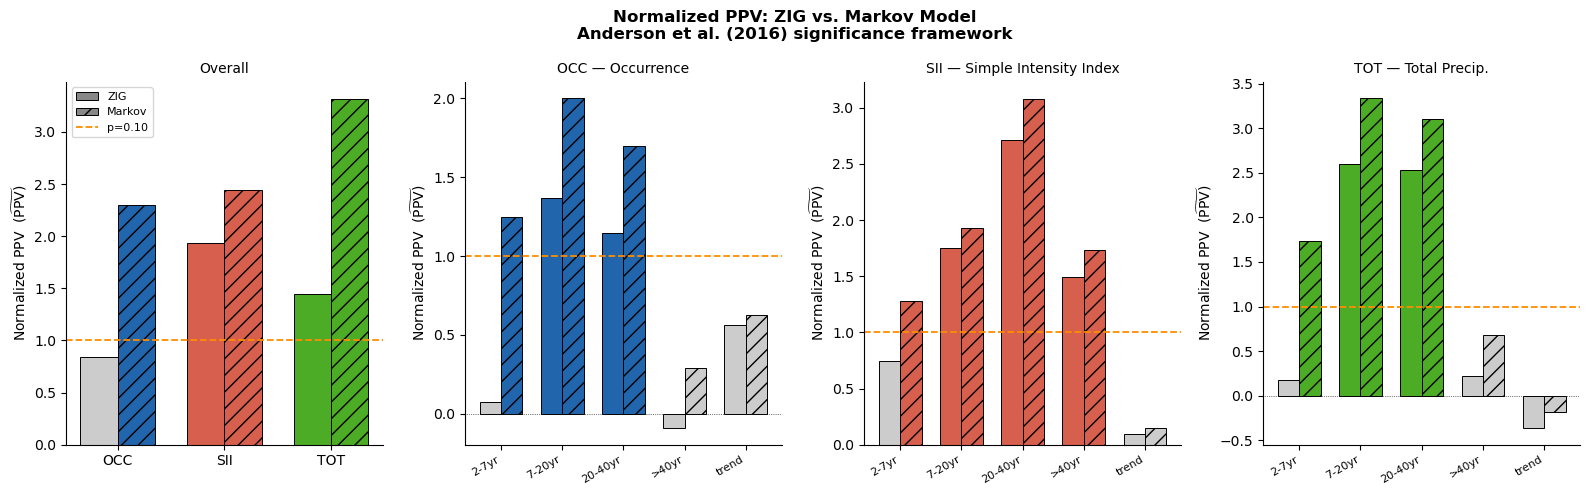

In [19]:
plot_ppv_comparison(
    ppv_norm_results=ppv_norm_results,
    ppv_spectral=ppv_spectral,
    ppv_norm_results_markov=ppv_norm_results_markov,
    ppv_spectral_markov=ppv_spectral_markov,
)